In [167]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import trange
from PIL import Image, ImageDraw

from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
    LinearDiffuser,
    ChannelProfiler,
)
from landlab.plot.graph import plot_graph

# 1 SPACE with Constant Rainfall as Runoff

**Description and the Equations of SPACE**

- key variable 01
- key variable 02

## Instantiate a grid

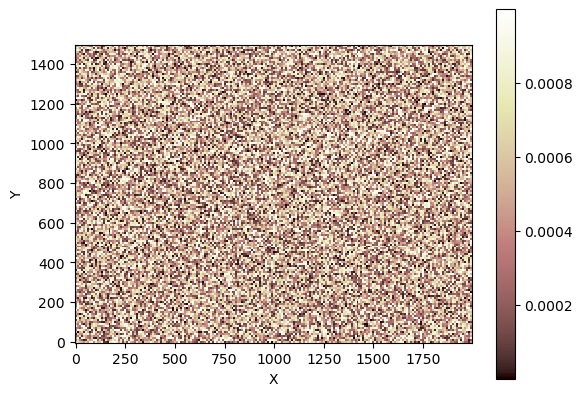

In [168]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

#### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [169]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

#### Set model time and uplift parameters

In [170]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.00001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [171]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

#### Run the fluvial model

In [172]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 1.0006938879715463
model run time 200000
maximum elevation 2.0004510054363505
model run time 300000
maximum elevation 3.0002782913350146
model run time 400000
maximum elevation 4.000194915640722
model run time 500000
maximum elevation 5.000131802837059
model run time 600000
maximum elevation 6.000089715510533
model run time 700000
maximum elevation 7.000064207010703
model run time 800000
maximum elevation 8.000052217817704
model run time 900000
maximum elevation 9.00003751271444
model run time 1000000
maximum elevation 10.000024682098678
model run time 1100000
maximum elevation 11.000017462476396
model run time 1200000
maximum elevation 12.000012451046452
model run time 1300000
maximum elevation 13.000008738273275
model run time 1400000
maximum elevation 14.00000686602208
model run time 1500000
maximum elevation 15.000005158951907
model run time 1600000
maximum elevation 16.00000254465875
model run time 1700000
maximum elevation 16.99976304203223

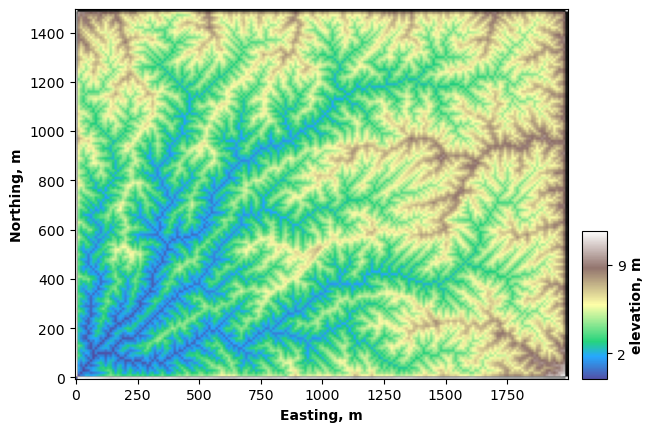

In [173]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

#### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

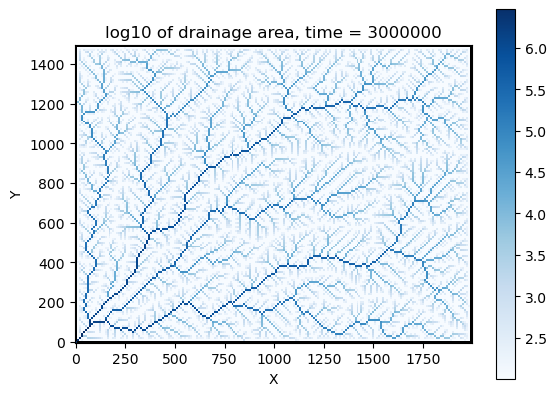

In [174]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Space Run

#### Initiate Channel Profiler

Find out how many nodes our channel has, so we can save information later about them in the for loop

Make empty arrays of size where the number of rows is the number of timesteps, and the number of columns is the number of nodes in our main channel.

In [175]:
profiler = ChannelProfiler(
    mg,)
profiler.run_one_step()

# lp = list(profiler.data_structure[0].values())[0]["ids"]
# lpn = np.zeros([30, 234])
# lpd = np.zeros([30, 234])
# lpe = np.zeros([30, 234])
lpn = []
lpd = []
lpe = []

In [176]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 10.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

In [177]:
ha = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=1,
    phi=0.1,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [178]:
Grid_topo = []
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

In [179]:
os.makedirs("Results/SpaceWithoutRunoff", exist_ok=True)

### This one takes 10 mins to run
space_dt = 10.0
df = DepressionFinderAndRouter(mg)
for _ in trange(30):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8")
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)

    profiler.run_one_step()
    ids = list(profiler.data_structure[0].values())[0]["ids"]
    distances = list(profiler.data_structure[0].values())[0]["distances"]
    # lpn[_, :] = list(profiler.data_structure[0].values())[0]["ids"]
    # lpd[_, :] = list(profiler.data_structure[0].values())[0]["distances"]
    # lpe[_, :] = mg.at_node["topographic__elevation"][lpn[_].astype(int)]
    lpn.append(ids)
    lpd.append(distances)
    lpe.append(mg.at_node["topographic__elevation"][ids.astype(int)])
    
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    elevation_grid = mg.at_node["topographic__elevation"].copy()
    Grid_topo.append(elevation_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.sca(axes[0])
    imshow_grid(mg, elevation_grid, cmap="Spectral", vmin=0, vmax=20)
    axes[0].set_title(f"Topographic Elevation at {_} years")
    plt.sca(axes[1])
    elev_diff = Grid_topo[0] - elevation_grid
    imshow_grid(mg, elev_diff, cmap="Spectral", vmin=0, vmax=10)

    axes[1].set_title(f"Accumulated Erosion at {_} year")
    plt.tight_layout()
    plt.savefig(f"Results/SpaceWithoutRunoff/SpaceWithoutRunoff_Year_{_:02d}.png", dpi=300)
    plt.close(fig)

100%|██████████| 30/30 [01:43<00:00,  3.44s/it]


#### Visualizing the Output

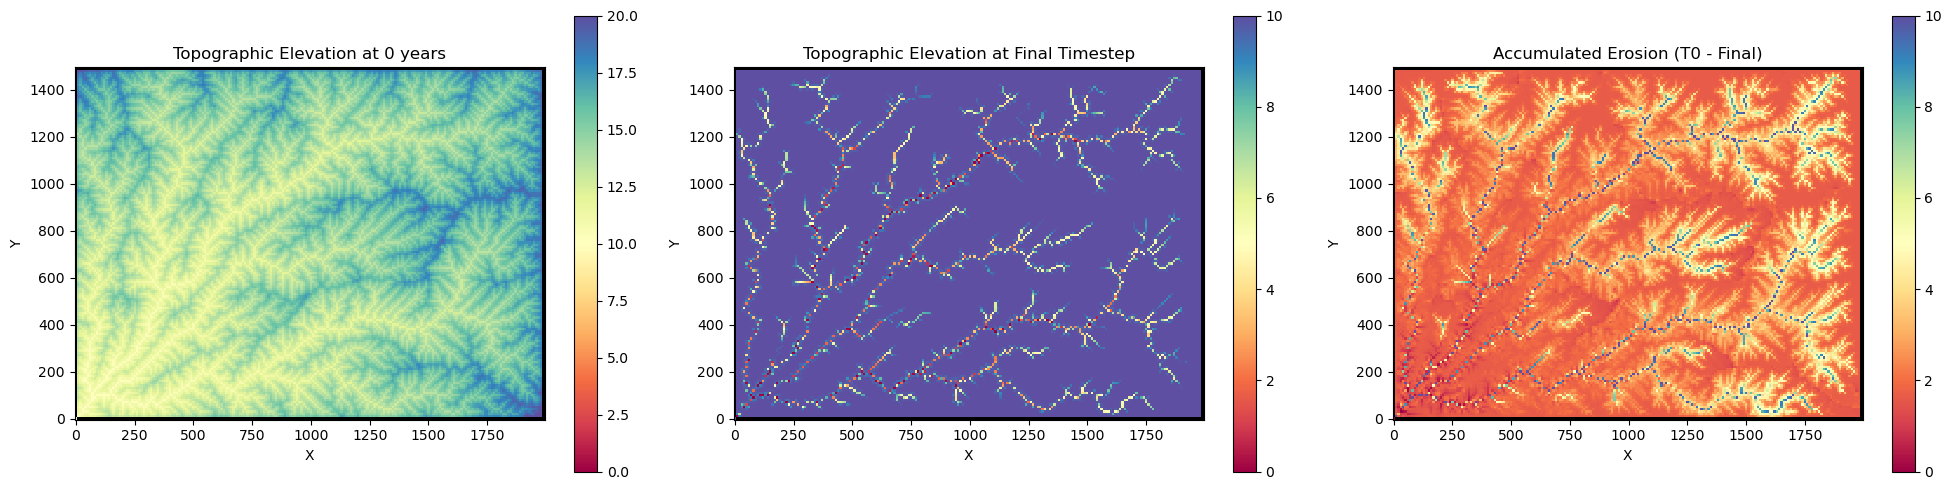

In [180]:
topoelvtn_diff = Grid_topo[0] - Grid_topo[-1]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.sca(axes[0])
imshow_grid(mg, Grid_topo[0], cmap="Spectral", vmin=0, vmax=20)
axes[0].set_title("Topographic Elevation at 0 years")
plt.sca(axes[1])
imshow_grid(mg, Grid_topo[-1], cmap="Spectral", vmin=0, vmax=10)
axes[1].set_title("Topographic Elevation at Final Timestep")
plt.sca(axes[2])
imshow_grid(mg, topoelvtn_diff, cmap="Spectral", vmin=0, vmax=10)
axes[2].set_title("Accumulated Erosion (T0 - Final)")
plt.tight_layout()
plt.show()

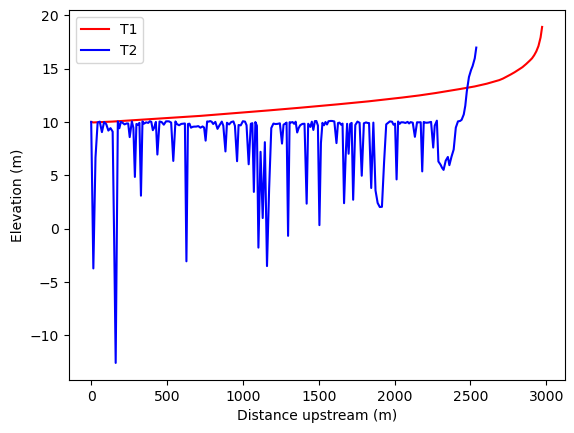

In [148]:
plt.plot(lpd[0], lpe[0], label="T1", color="red")
plt.plot(lpd[-1], lpe[-1], label="T2", color="blue")
plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

# 2 Space with Variable Rainfall as Runoff

## Instantiate a grid

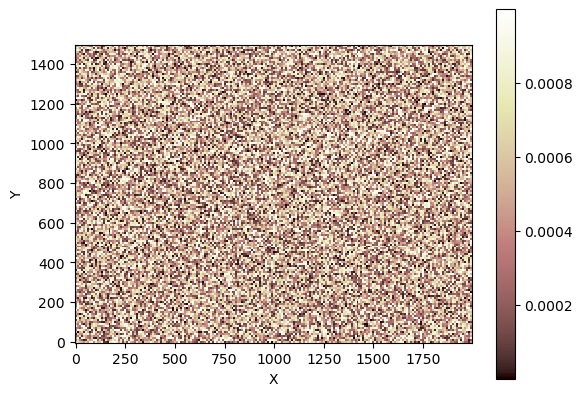

In [181]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

#### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [182]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

#### Set model time and uplift parameters

In [183]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.00001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [184]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

#### Run the fluvial model

In [185]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 1.0006938879715463
model run time 200000
maximum elevation 2.0004510054363505
model run time 300000
maximum elevation 3.0002782913350146
model run time 400000
maximum elevation 4.000194915640722
model run time 500000
maximum elevation 5.000131802837059
model run time 600000
maximum elevation 6.000089715510533
model run time 700000
maximum elevation 7.000064207010703
model run time 800000
maximum elevation 8.000052217817704
model run time 900000
maximum elevation 9.00003751271444
model run time 1000000
maximum elevation 10.000024682098678
model run time 1100000
maximum elevation 11.000017462476396
model run time 1200000
maximum elevation 12.000012451046452
model run time 1300000
maximum elevation 13.000008738273275
model run time 1400000
maximum elevation 14.00000686602208
model run time 1500000
maximum elevation 15.000005158951907
model run time 1600000
maximum elevation 16.00000254465875
model run time 1700000
maximum elevation 16.99976304203223

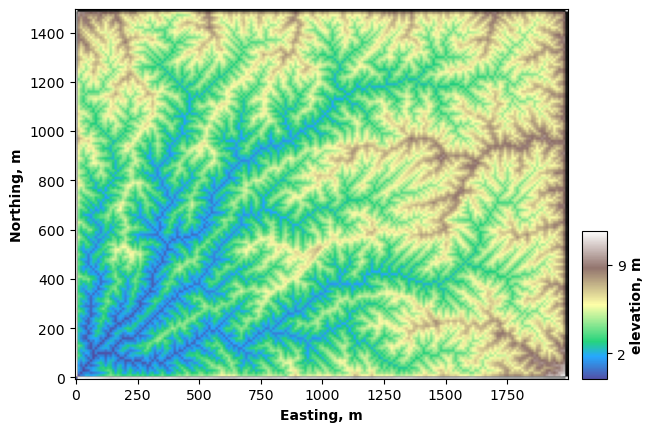

In [186]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

#### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

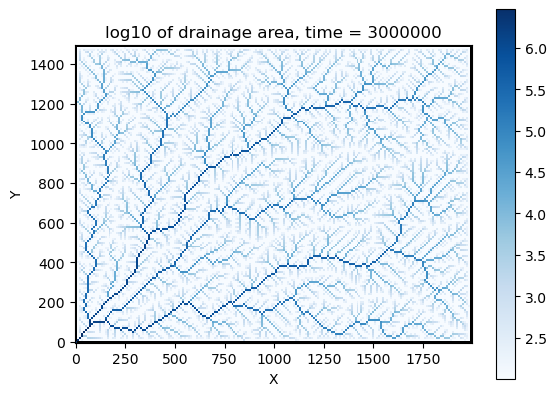

In [187]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Space Run

#### Initiate Channel Profiler

Find out how many nodes our channel has, so we can save information later about them in the for loop

Make empty arrays of size where the number of rows is the number of timesteps, and the number of columns is the number of nodes in our main channel.

In [188]:
profiler = ChannelProfiler(
    mg,)
profiler.run_one_step()

# lp = list(profiler.data_structure[0].values())[0]["ids"]
# lpn = np.zeros([30, 234])
# lpd = np.zeros([30, 234])
# lpe = np.zeros([30, 234])
lpn = []
lpd = []
lpe = []

#### Variable Runoff Creation

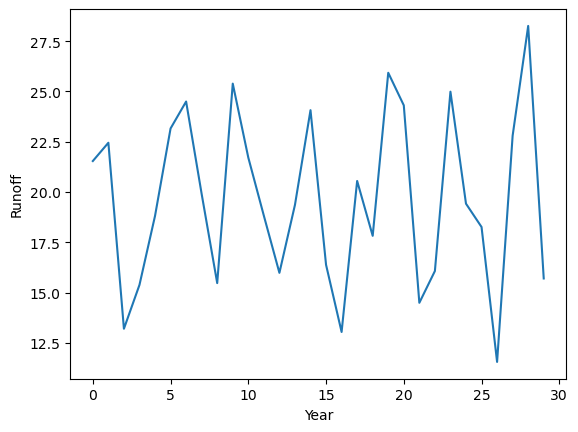

In [189]:
runoff_array = np.array([21.54, 22.45, 13.2, 15.38, 18.81, 23.16, 24.5, 19.9, 15.47, 25.39,
                          21.71, 18.82, 15.98, 19.36, 24.07, 16.38, 13.04, 20.55, 17.82, 25.93,
                          24.31, 14.49, 16.07, 24.99, 19.42, 18.26, 11.55, 22.8, 28.26, 15.7])

# np.random.seed(33)
# runoff_array = np.random.uniform(15, 30, 30)

plt.plot(runoff_array)
plt.xlabel("Year")
plt.ylabel("Runoff")
plt.show()

#### Preparation and Running Space

In [190]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 10.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

In [191]:
ha = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=1,
    phi=0.1,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [192]:
Grid_topo = []
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

# mg.at_node["topographic__elevation"][0],
# mg.at_node["sediment__influx"][0],
# mg.at_node["sediment__outflux"][0], 
# mg.at_node["bedrock__elevation"][0],
# mg.at_node["surface_water__discharge"][0]

In [ ]:
### This one takes 15 mins to run

os.makedirs("Results/SpaceWithRunoff", exist_ok=True)

space_dt = 10.0
df = DepressionFinderAndRouter(mg) 
for _ in trange(30):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)

    profiler.run_one_step()
    ids = list(profiler.data_structure[0].values())[0]["ids"]
    distances = list(profiler.data_structure[0].values())[0]["distances"]
    # lpn[_, :] = list(profiler.data_structure[0].values())[0]["ids"]
    # lpd[_, :] = list(profiler.data_structure[0].values())[0]["distances"]
    # lpe[_, :] = mg.at_node["topographic__elevation"][lpn[_].astype(int)]
    lpn.append(ids)
    lpd.append(distances)
    lpe.append(mg.at_node["topographic__elevation"][ids.astype(int)])
    
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    elevation_grid = mg.at_node["topographic__elevation"].copy()
    Grid_topo.append(elevation_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    imshow_grid(mg, elevation_grid, cmap="Spectral", vmin=0, vmax=20)
    axes[0].set_title(f"Topographic Elevation at {_} years")

    plt.sca(axes[1])
    elev_diff = Grid_topo[0] - elevation_grid
    imshow_grid(mg, elev_diff, cmap="Spectral", vmin=0, vmax=10)
    axes[1].set_title(f"Accumulated Erosion at {_} year")

    plt.tight_layout()
    plt.savefig(f"Results/SpaceWithRunoff/SpaceWithRunoff_Year_{_:02d}.png", dpi=300)
    plt.close(fig)

  0%|          | 0/30 [00:00<?, ?it/s]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  3%|▎         | 1/30 [00:03<01:33,  3.23s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  7%|▋         | 2/30 [00:06<01:31,  3.27s/it]

...

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


 57%|█████▋    | 17/30 [03:07<05:24, 24.99s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


 60%|██████    | 18/30 [03:42<05:37, 28.11s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


#### Visualizing the Output

In [ ]:
topoelvtn_diff = Grid_topo[0] - Grid_topo[-1]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.sca(axes[0])
imshow_grid(mg, Grid_topo[0], cmap="Spectral", vmin=0, vmax=20)
axes[0].set_title("Topographic Elevation at 0 years")
plt.sca(axes[1])
imshow_grid(mg, Grid_topo[-1], cmap="Spectral", vmin=0, vmax=10)
axes[1].set_title("Topographic Elevation at Final Timestep")
plt.sca(axes[2])
imshow_grid(mg, topoelvtn_diff, cmap="Spectral", vmin=0, vmax=10)
axes[2].set_title("Accumulated Erosion (T0 - Final)")
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(lpd[0], lpe[0], label="T1", color="red")
plt.plot(lpd[-1], lpe[-1], label="T2", color="blue")
plt.xlabel("Distance upstream (m)")
plt.ylabel("Elevation (m)")
plt.legend()
plt.show()

# 3 Visual Comparision

In [ ]:
files_a = glob.glob("Results/SpaceWithoutRunoff/SpaceWithoutRunoff_Year_*.png")
files_a.sort(key=lambda f: int(re.search(r"Year_(\d+)", os.path.basename(f)).group(1)))

files_b = glob.glob("Results/SpaceWithRunoff/SpaceWithRunoff_Year_*.png")
files_b.sort(key=lambda f: int(re.search(r"Year_(\d+)", os.path.basename(f)).group(1)))

frames = []
for fa, fb in zip(files_a, files_b):
    img_a = Image.open(fa)
    img_b = Image.open(fb)

    h = max(img_a.height, img_b.height)
    combined = Image.new("RGB", (img_a.width + img_b.width, h), "white")
    combined.paste(img_a, (0, 0))
    combined.paste(img_b, (img_a.width, 0))

    draw = ImageDraw.Draw(combined)
    year = re.search(r"Year_(\d+)", os.path.basename(fa)).group(1)
    draw.text((10, 10), f"Left: Without Runoff | Right: With Runoff | Year {year}", fill="black")

    frames.append(combined)

gif_path = "Results/comparison.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=400, loop=0)


display(IPImage(filename=gif_path))